# RNN 語言模型

## 文字的處理

讀取 `data/shakespeare.txt` 文字檔的內容，並對檔案中的字元做基本統計與預覽，包含：

- 計算整份文字的總字元數
- 建立不重複字元的字元表
- 計算字元表大小
- 顯示字元表前 10 個字元
- 顯示原始文字前 148 個字元內容

In [8]:
# 指定要讀取的文字檔路徑
filename = "data/shakespeare.txt"

# 讀取整個文字檔內容
data = open(filename, "r").read()
# 取得資料中所有不重複字元，建立字元表
chars = list(set(data))
# 計算全文字元總數與不重複字元數量
data_size, vocab_size = len(data), len(chars)

# 輸出資料集的基本統計資訊
print("字元總數 %d, 字符表的長度 %d unique." % (data_size, vocab_size))
# 顯示字元表中的前 10 個字元，方便快速查看字元組成
print("字元表中的前 10 個字元：\n", chars[:10])
# 顯示原始文字前 148 個字元，作為資料內容預覽
print("前 148 個字元：\n", data[:148])

字元總數 1115394, 字符表的長度 65 unique.
字元表中的前 10 個字元：
 ['x', 'k', 'L', "'", 'X', ',', 'e', 's', '\n', ';']
前 148 個字元：
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?



這段程式碼延續前面的字元表處理結果，進一步建立字元與索引之間的雙向映射，並定義一個 `one_hot_idx` 函式，將指定索引轉成 one-hot 向量表示。

這樣的做法是將字元改為量化後的數字，才能被電腦所處理。

In [9]:
import numpy as np

# 建立字元到索引的映射表，方便將文字資料轉成模型可處理的數值表示
char_to_idx = {ch: i for i, ch in enumerate(chars)}

# 建立索引到字元的映射表，方便之後將模型輸出還原成文字
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# 輸出雙向映射內容，確認字元表與索引配置是否正確
print("字元到索引的映射：\n", char_to_idx)
print("索引到字元的映射：\n", idx_to_char)


def one_hot_idx(idx, vocab_size):
    # 建立一個大小為 (1, vocab_size) 的全 0 向量
    x = np.zeros((1, vocab_size))

    # 將指定索引位置設為 1，形成 one-hot 表示
    x[0, idx] = 1

    # 回傳 one-hot 向量
    return x


# 測試 one_hot_idx 函數，將索引 1 轉換為 one-hot 向量
test_idx = 1
one_hot_vector = one_hot_idx(char_to_idx["B"], vocab_size)

# 輸出測試結果
print("索引 %d 的 one-hot 向量：\n" % test_idx, one_hot_vector)

字元到索引的映射：
 {'x': 0, 'k': 1, 'L': 2, "'": 3, 'X': 4, ',': 5, 'e': 6, 's': 7, '\n': 8, ';': 9, 'n': 10, 'T': 11, 'a': 12, 'o': 13, 'p': 14, 'q': 15, 'f': 16, 'O': 17, 'R': 18, 'l': 19, '&': 20, ' ': 21, 'F': 22, 'h': 23, 'I': 24, 'B': 25, 'y': 26, 'E': 27, 'J': 28, 'S': 29, 'W': 30, 'V': 31, 'v': 32, 'H': 33, '3': 34, 'N': 35, 'd': 36, 'c': 37, 'M': 38, 'm': 39, ':': 40, 'K': 41, 'j': 42, 'D': 43, 'b': 44, 'A': 45, '.': 46, 'i': 47, 'w': 48, '!': 49, '?': 50, 'Y': 51, '$': 52, '-': 53, 'z': 54, 'C': 55, 'g': 56, 'G': 57, 'Q': 58, 't': 59, 'P': 60, 'u': 61, 'Z': 62, 'U': 63, 'r': 64}
索引到字元的映射：
 {0: 'x', 1: 'k', 2: 'L', 3: "'", 4: 'X', 5: ',', 6: 'e', 7: 's', 8: '\n', 9: ';', 10: 'n', 11: 'T', 12: 'a', 13: 'o', 14: 'p', 15: 'q', 16: 'f', 17: 'O', 18: 'R', 19: 'l', 20: '&', 21: ' ', 22: 'F', 23: 'h', 24: 'I', 25: 'B', 26: 'y', 27: 'E', 28: 'J', 29: 'S', 30: 'W', 31: 'V', 32: 'v', 33: 'H', 34: '3', 35: 'N', 36: 'd', 37: 'c', 38: 'M', 39: 'm', 40: ':', 41: 'K', 42: 'j', 43: 'D', 44: 'b', 45: 

## 字元序列樣本採樣

這段程式碼定義了一個 `character_seq_data_iter_consecutive` 產生器函式，用來從文字資料中，以「連續切分」的方式產生訓練用序列批次資料。

它的主要用途是把原始字元序列切成多個 batch，並在每個 batch 中持續取出固定長度的序列片段，供序列模型訓練使用。每次輸出會同時提供：

- `X`：目前時間步的輸入序列
- `Y`：對應下一個字元的目標序列
- 是否為該輪第一個 batch 的標記值

In [10]:
import numpy as np


def character_seq_data_iter_consecutive(data, batch_size, seq_len, start_range=10):
    # 每次從隨機偏移位置開始切資料，讓不同 epoch 的切法略有變化
    start = np.random.randint(0, start_range)

    # 計算每個 batch 區塊可使用的有效資料長度
    # -1 是為了保留給目標序列 Y 使用的下一個位置
    block_len = (len(data) - start - 1) // batch_size

    # 計算每個區塊最多可以切出幾個完整的 seq_len 序列
    num_batches = block_len // seq_len

    # 建立每個 batch 樣本對應的區塊起始位置
    # 每個樣本都從不同區塊開始取連續資料
    bs = np.array(range(0, block_len * batch_size, block_len))

    # 可實際使用的總序列長度，避免取到不完整片段
    i_end = num_batches * seq_len

    # 依序取出每段長度為 seq_len 的連續序列
    for i in range(0, i_end, seq_len):  # i 表示單一區塊內目前切到的相對起始位置
        s = start + i  # 換算成原始資料中的實際起始位置

        # 建立輸入序列 X 與目標序列 Y
        # 維度為 (seq_len, batch_size)，第一維是時間步，第二維是 batch
        X = np.empty((seq_len, batch_size), dtype=object)
        Y = np.empty((seq_len, batch_size), dtype=object)

        # 逐一填入 batch 中每個樣本的序列內容
        for b in range(batch_size):  # b 表示 batch 中第幾個樣本
            s_b = s + bs[b]  # 目前樣本在原始資料中的起始位置

            # 依時間步填入輸入與對應的下一步目標
            for t in range(seq_len):
                X[t, b] = data[s_b]
                Y[t, b] = data[s_b + 1]
                s_b += 1

        # 第一個 batch 額外回傳 True，供外部流程判斷是否為新一輪起始
        if i == 0:
            yield X, Y, True
        else:
            yield X, Y, False

測試這個資料產生器是否能正確產生序列批次資料。

In [11]:
# 建立測試用字串資料
x = "Li,where are you from"

# 設定每個 batch 的樣本數
batch_size = 2

# 設定序列長度（每個樣本的時間步長）
seq_length = 3

# 建立連續序列資料迭代器
data_it = character_seq_data_iter_consecutive(x, batch_size, seq_length, 1)

# 用來控制只觀察前幾個 batch
i = 0

# 逐批從資料迭代器取出序列資料
for x, y, _ in data_it:

    # 印出輸入序列
    print("x:", x)

    # 印出對應的目標序列（下一個字元）
    print("y", y)

    # 批次計數
    i += 1

    # 只顯示前兩個 batch
    if i == 2:
        break

x: [['L' 'r']
 ['i' 'e']
 [',' ' ']]
y [['i' 'e']
 [',' ' ']
 ['w' 'y']]
x: [['w' 'y']
 ['h' 'o']
 ['e' 'u']]
y [['h' 'o']
 ['e' 'u']
 ['r' ' ']]


這段程式碼將先前的連續序列資料產生器進一步擴充，讓輸入 `X` 直接轉成 one-hot 編碼格式，並將目標 `Y` 轉成對應字元索引，方便後續直接拿來做字元級序列模型訓練。


In [12]:
def character_seq_data_iter_consecutive(
    data, batch_size, seq_len, vocab_size, start_range=10
):
    # 隨機決定本輪資料切分的起始偏移，讓不同 epoch 的切法略有變化
    start = np.random.randint(0, start_range)

    # 計算每個 batch block 可使用的有效資料長度
    # -1 是因為標籤 Y 需要對應到下一個字元
    block_len = (len(data) - start - 1) // batch_size

    # 計算每個 block 最多可切出幾個完整的 seq_len 批次
    num_batches = block_len // seq_len

    # 建立每個 block 在原始資料中的起始偏移量
    bs = np.array(range(0, block_len * batch_size, block_len))

    # 可實際使用的總時間步數，避免超出完整批次範圍
    i_end = num_batches * seq_len

    # 依 seq_len 為單位，逐段取出固定長度的連續序列
    for i in range(0, i_end, seq_len):
        # 本批次在原始資料中的起始位置
        s = start + i

        # X: 輸入序列，使用 one-hot 表示字元
        # shape = (seq_len, batch_size, vocab_size)
        X = np.empty((seq_len, batch_size, vocab_size), dtype=np.int32)

        # Y: 目標序列，儲存下一個字元的索引
        # shape = (seq_len, batch_size, 1)
        Y = np.empty((seq_len, batch_size, 1), dtype=np.int32)

        # 逐一處理 batch 中的每個樣本
        for b in range(batch_size):
            # 取得第 b 個 block 在本批次中的起始位置
            s_b = s + bs[b]

            # 依時間步填入輸入 X 與標籤 Y
            for t in range(seq_len):
                # 目前字元轉為索引後，再轉成 one-hot 向量作為輸入
                X[t, b, :] = one_hot_idx(char_to_idx[data[s_b]], vocab_size)

                # 下一個字元的索引作為預測目標
                Y[t, b, :] = char_to_idx[data[s_b + 1]]

                # 往下一個時間步前進
                s_b += 1

        # 第一個 batch 額外回傳 True，供外部流程判斷是否為起始批次
        if i == 0:
            yield X, Y, True
        else:
            yield X, Y, False

In [13]:
# 建立測試用字串
x = "Li,where are you from"

# 設定 batch 大小（每個時間步同時處理的序列數量）
batch_size = 2

# 設定序列長度（每個樣本的時間步數）
seq_length = 3

# 建立資料迭代器（generator）
data_it = character_seq_data_iter_consecutive(x, batch_size, seq_length, vocab_size, 1)

# 用來限制只印出前兩個 batch
i = 0

# 逐批讀取資料
for x, y, _ in data_it:
    # 印出輸入資料（one-hot 編碼後）
    print("x:", x)

    # 印出標籤資料（下一個字元的索引）
    print("y", y)

    # 記錄已讀取的 batch 數量
    i += 1

    # 只顯示前兩個 batch，避免輸出過多
    if i == 2:
        break

x: [[[0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]]

 [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
  [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

 [[0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
   0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]]
y [[[47]
  [ 6]]

 [[ 5]
  [21]]

 [[48]
  [26]]]
x: [[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 

## 定義RNN模型

這段程式碼主要是在初始化一個 RNN（Recurrent Neural Network）的基本運行環境，包含模型參數與初始隱藏狀態（hidden state）。透過自定義模組 `modules.rnn`（別名 `fr`）來建立 RNN 所需的權重與狀態。

- 設定 RNN 的基本超參數（input/output 維度、hidden size、batch size）
- 呼叫自定義函式初始化模型參數（weights / biases）
- 初始化 RNN 的隱藏狀態，用於序列運算起點

In [19]:
import numpy as np
import rnn as rnn # 匯入自定義 RNN 模組，並使用 fr 作為別名

# ===== 基本參數設定 =====
batch_size = 1  # 每次輸入的樣本數（batch size）
input_dim = vocab_size  # 輸入維度，通常為詞彙表大小（one-hot 或 embedding 前）
output_dim = vocab_size  # 輸出維度，對應詞彙預測空間
hidden_size = 100  # RNN 隱藏層維度（hidden state 大小）

# ===== 初始化 RNN 參數 =====
# 包含權重矩陣與偏置項（實際內容由 modules.rnn 決定）
params = rnn.rnn_params_init(input_dim, hidden_size, output_dim)

# ===== 初始化 hidden state =====
# 建立初始隱藏狀態，通常為全 0，shape 為 (batch_size, hidden_size)
H = rnn.rnn_hidden_state_init(batch_size, hidden_size)

這段程式碼實作了 RNN 前向傳播的兩個層次：單一步驟的前向計算，以及整段序列的前向計算。`rnn_forward_step` 負責處理單一時間步的輸入與前一個 hidden state，產生目前時間步的 hidden state 與輸出；`rnn_forward_` 則負責逐步走訪整個輸入序列，收集每個時間步的輸出與 hidden state。

In [20]:
def rnn_forward_step(params, X, preH):
    # 由參數列表中取出各權重矩陣與偏置項
    Wx, Wh, bh, Wf, bf = params

    # 計算目前時間步的 hidden state
    # 結合目前輸入 X 與前一個 hidden state preH，再經過 tanh 活化
    H = np.tanh(np.dot(X, Wx) + np.dot(preH, Wh) + bh)

    # 依據目前 hidden state 計算輸出值
    F = np.dot(H, Wf) + bf

    # 回傳目前時間步的輸出與 hidden state
    return F, H


def rnn_forward_(params, Xs, H_):
    # 由參數列表中取出各權重矩陣與偏置項
    Wx, Wh, bh, Wf, bf = params

    # 使用傳入的初始 hidden state 作為序列起點
    H = H_

    # Fs 用來依序儲存每個時間步的輸出
    Fs = []

    # Hs 用來記錄每個時間步的 hidden state
    Hs = {}

    # 保留初始 hidden state，方便後續追蹤前一時刻狀態
    Hs[-1] = np.copy(H)

    # 逐一處理整段輸入序列
    for t in range(len(Xs)):
        # 取得目前時間步的輸入
        X = Xs[t]

        # 執行單一步驟的前向傳播，更新輸出與 hidden state
        F, H = rnn_forward_step(params, X, H)

        # 紀錄目前時間步的輸出
        Fs.append(F)

        # 紀錄目前時間步的 hidden state
        Hs[t] = H

    # 回傳整段序列的輸出與所有 hidden state
    return Fs, Hs

這段程式碼實作的是 RNN 的文字生成流程，根據給定的前綴字串 `prefix`，逐步預測後續字元，總共額外生成 `n` 個時間步的內容。函式會先將前綴的第一個字元作為起始輸入，接著在每個時間步中，使用前一個輸出的字元作為下一步輸入，透過 RNN 前向計算取得輸出分數，再轉成機率分佈做抽樣，產生下一個字元。

In [21]:
def predict_rnn(params, prefix, n):
    # 由參數列表中取出 RNN 權重與偏置
    Wx, Wh, bh, Wf, bf = params

    # Wxh, Whh,Why, bh, by =params["Wxh"],params["Whh"],params["Why"],params["bh"],params["by"]

    # 由權重矩陣形狀取得詞彙大小與 hidden state 維度
    vocab_size, hidden_size = Wx.shape[0], Wh.shape[1]

    # 初始化 batch size = 1 的 hidden state
    h = rnn.rnn_hidden_state_init(1, hidden_size)

    # 先將 prefix 的第一個字元作為起始輸出
    output = [char_to_idx[prefix[0]]]

    # 依 prefix 長度與欲生成長度，逐步往後預測
    for t in range(len(prefix) + n - 1):
        # 將上一時間步的輸出作為目前時間步的輸入
        x = one_hot_idx(output[-1], vocab_size)

        # 執行單一步驟前向傳播，取得輸出分數與新的 hidden state
        z, h = rnn_forward_step(params, x, h)

        # h = np.tanh(np.dot(x,Wx) + np.dot(h,Wh) + bh)
        # z = np.dot(h,Wf) + bf

        # 在 prefix 範圍內時，直接使用 prefix 的下一個字元
        if t < len(prefix) - 1:
            output.append(char_to_idx[prefix[t + 1]])
        else:
            # 將輸出分數轉為機率分佈
            p = np.exp(z) / np.sum(np.exp(z))

            # idx = int(p.argmax(axis=1))

            # 依機率分佈隨機抽樣下一個字元索引
            idx = np.random.choice(range(vocab_size), p=p.ravel())
            output.append(idx)

    # 將索引序列轉回字元並組成最終字串
    return "".join([idx_to_char[i] for i in output])

In [22]:
str = predict_rnn(params, "he", 200)
print(str)

heTEmsbS-EFV:ZCxj?'DI-uU:Ig
Hbzes&DkN.j'AVU;;vH'?CphjWHtFgBk3TNODQf-bSaBE3lnRLFT Y-Fh:hyKqTiCqIzA HdWcOJjxuAe3n-jBu'Mk$QdyV!!
 Jq'TW-W!TXdzRux:;JG!bxQ&$hgQwG,:puzP?ewttSklRFXrPn& nhC!fVETva;KVQXRm
iNDY&


## 訓練

這段程式碼實作的是 RNN 單一訓練 epoch 的主要流程。函式會從資料迭代器 `data_iter` 逐批取得輸入序列與對應標籤，依序執行 hidden state 初始化、前向傳播、loss 計算、反向傳播與參數更新，並在訓練過程中記錄每次迭代的 loss。最後會回傳整個 epoch 的 loss 紀錄，以及目前保留下來的 hidden state。

In [30]:
def rnn_train_epoch(
    params, data_iter, optimizer, iterations, loss_function, print_n=100
):
    # 由參數列表中取出 RNN 權重與偏置
    Wx, Wh, bh, Wf, bf = params

    # 紀錄每次迭代的 loss
    losses = []

    # 迭代計數器
    iter = 0

    # 由 hidden-to-hidden 權重矩陣取得 hidden state 維度
    hidden_size = Wh.shape[0]

    # 逐批讀取訓練資料
    for Xs, Ys, start in data_iter:

        # 由目前 batch 的第一個時間步輸入推得 batch size
        batch_size = Xs[0].shape[0]

        # 若為新序列起點，則重新初始化 hidden state
        if start:
            H = rnn.rnn_hidden_state_init(batch_size, hidden_size)

        # 執行前向傳播，取得各時間步輸出與 hidden state
        Zs, Hs = rnn.rnn_forward(params, Xs, H)

        # 計算 loss，並取得對輸出層的梯度
        loss, dzs = loss_function(Zs, Ys)

        # 保留除錯用輸出區塊，目前不執行
        if False:
            print("Z.shape", Zs[0].shape)
            print("Y.shape", Ys[0].shape)
            print("H", H.shape)

        # 執行反向傳播，取得各參數梯度
        dWx, dWh, dbh, dWf, dbf = rnn.rnn_backward(params, Xs, Hs, dzs)

        # 取出最後一個時間步保留下來的 hidden state
        # 供下一批次延續使用
        H = Hs[len(Hs) - 2]  # 最後時刻的隱狀態向量

        # 整理梯度列表，交由 optimizer 更新參數
        grads = [dWx, dWh, dbh, dWf, dbf]
        optimizer.step(grads)

        # 紀錄目前 loss
        losses.append(loss)

        # 每隔固定次數輸出目前訓練資訊
        if iter % print_n == 0:
            print("iter %d, loss: %f" % (iter, loss))

        iter += 1

        # 達到指定迭代數後停止
        if iter > iterations:
            break

    # 回傳整個 epoch 的 loss 紀錄與最後保留的 hidden state
    return losses, H

這段程式碼是在設定並執行 RNN 的訓練流程，包含模型參數初始化、loss function 與 optimizer 設定、依 epoch 反覆訓練，以及最後將所有訓練過程中的 loss 畫成曲線。整體來看，這是模型訓練主流程的外層控制段落，負責串接前面定義好的資料迭代器、訓練函式與視覺化結果。

iter 0, loss: 104.358359
iter 10, loss: 97.459218
iter 20, loss: 84.579077
iter 30, loss: 75.855728
iter 40, loss: 80.115397
iter 50, loss: 83.405840
iter 60, loss: 85.149035
iter 70, loss: 77.070094
iter 80, loss: 74.718012
iter 90, loss: 73.016082
iter 100, loss: 69.037846
iter 110, loss: 72.983020
iter 120, loss: 69.665091
iter 130, loss: 75.547254
iter 140, loss: 69.588983
iter 150, loss: 69.748402
iter 160, loss: 68.269086
iter 170, loss: 71.266218
iter 180, loss: 73.218733
iter 190, loss: 65.839896
iter 200, loss: 67.756091
iter 210, loss: 64.208381
iter 220, loss: 72.436201
iter 230, loss: 57.996663
iter 240, loss: 62.466670
iter 250, loss: 74.693438
iter 260, loss: 61.790403
iter 270, loss: 61.977232
iter 280, loss: 57.902645
iter 290, loss: 77.716687
iter 300, loss: 60.325612
iter 310, loss: 65.432157
iter 320, loss: 60.053415
iter 330, loss: 61.909152
iter 340, loss: 65.840538
iter 350, loss: 65.732744
iter 360, loss: 64.132347
iter 370, loss: 61.563154
iter 380, loss: 60.268

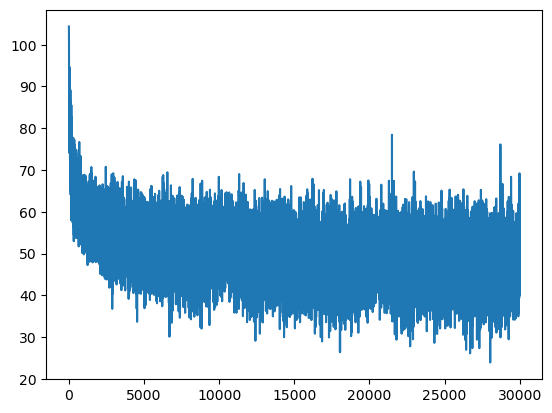

In [31]:
import matplotlib.pyplot as plt

# ===== 模型與資料維度設定 =====
batch_size = 3
input_dim = vocab_size
output_dim = vocab_size
hidden_size = 100

# 初始化 RNN 參數（包含輸入、hidden、輸出層權重與偏置）
params = rnn.rnn_params_init(input_dim, hidden_size, output_dim)

# 初始化 hidden state（作為第一個 batch 的起始狀態）
H = rnn.rnn_hidden_state_init(batch_size, hidden_size)

# 每段序列的時間步長度（Truncated BPTT 長度）
seq_length = 25

# ===== loss function 設定 =====
# 將 loss 與 gradient 計算封裝成統一介面
loss_function = lambda F, Y: rnn.rnn_loss_grad(F, Y)

# ===== 訓練超參數設定 =====
epoches = 3
learning_rate = 1e-2
iterations = 10000

# 用來累積所有 epoch 的 loss（逐 iteration）
losses = []

# ===== optimizer 設定 =====
# 先建立 AdaGrad（後續會被覆蓋）
optimizer = rnn.AdaGrad(params, learning_rate)

momentum = 0.9
# 使用 SGD + momentum 作為最終 optimizer
optimizer = rnn.SGD(params, learning_rate, momentum)

# ===== 開始訓練 =====
for epoch in range(epoches):
    # 建立連續式序列資料迭代器
    data_it = character_seq_data_iter_consecutive(
        data, batch_size, seq_length, vocab_size, 100
    )

    # epoch_losses,param,H = rnn_train(params,data_it,learning_rate,iterations,loss_function,print_n=100)

    # 執行單一 epoch 訓練
    # 回傳該 epoch 的所有 iteration loss 與最後 hidden state
    epoch_losses, H = rnn_train_epoch(
        params, data_it, optimizer, iterations, loss_function, print_n=10
    )

    # 將本次 epoch 的 loss 累加到總 loss 紀錄
    losses.extend(epoch_losses)

    # （保留）若要改為記錄 epoch 平均 loss，可使用以下方式
    # epoch_losses = np.array(epoch_losses).mean()
    # losses.append(epoch_losses)

# ===== 繪製訓練 loss 曲線 =====
plt.plot(losses[:])

## 測試生成文字

可以看得出來雖然生成不少毫無意義的文字，但會接近一般英文單字的感覺，而不是毫無章法的各種亂碼。

In [ ]:
str = predict_rnn(params, "he", 500)
print(str)

he fins comfs thought,
Myour, sumeer this landly, while; looke, thou for.

PESTIO:
Your ast like: ad pather cratute may ingaid you, be acaare,
Howad,
The wish comasuig or un'd Hordan.
Whene fath a bendearustely shathers,
Hing hnor hine breatess, the pritle I and a rropleets:
Tour exores flaid,
But or erroce as ill I tee though a ly:
Gony was to'd slecome to wheln ithile, Hore repicess bestrance; good nor ghoy.

HARWARD:
Pranch on thaty, nuclloman,
And tall matharse, mine gurteng is ligerce, readey
